# 🚁 DIP Project — Gün 14: Hata Analizi (FP / FN)
Modelin başarısız olduğu örnekleri analiz et ve hata modlarını kategorize et.

**Analiz edilecekler:**
- False Positive (FP): Model nesne görüyor ama yok
- False Negative (FN): Gerçek nesne var ama model kaçırıyor
- Hata kategorileri: boyut, occlusion, sınıf karışıklığı

> **Gereksinim:** Gün 5 modeli ve Gün 11 eval sonuçları hazır olmalı.

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(args))

pip('numpy>=1.23,<2', '--force-reinstall')
pip('ultralytics>=8.3.0', 'sahi==0.11.15', 'supervision>=0.21.0', 'thop')

print('=' * 55)
print('✅ Kurulum tamam!')
print()
print('  >>> Runtime > Restart Runtime yap <<<')
print('  Restart sonrası bu hücreyi ATLA, sonrakinden başla!')
print('=' * 55)

✅ Kurulum tamam!

  >>> Runtime > Restart Runtime yap <<<
  Restart sonrası bu hücreyi ATLA, sonrakinden başla!


In [1]:
MODEL_PATH   = '/content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt'
PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
YAML_PATH   = f'{PROJECT_DIR}/data.yaml'
import os
print('MODEL_PATH:', MODEL_PATH)
print('Dosya var mı:', os.path.exists(MODEL_PATH))


MODEL_PATH: /content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt
Dosya var mı: False


In [3]:
# ▶️ Restart sonrası buradan başla
import torch, os, cv2, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
from collections import defaultdict

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {DEVICE}')

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
OUT_DIR      = f'{PROJECT_DIR}/error_analysis'
os.makedirs(OUT_DIR, exist_ok=True)

meta_path = f'{PROJECT_DIR}/model_paths.json'
if os.path.exists(meta_path):
    with open(meta_path) as f:
        MODEL_PATH = json.load(f)['best_model']
else:
    MODEL_PATH = 'yolov8n.pt'
    print('⚠️  Gün 5 modeli bulunamadı — yolov8n.pt ile devam')

yolo_model = YOLO('/content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt')

CLASS_NAMES = ['pedestrian','people','bicycle','car','van',
               'truck','tricycle','awning-tricycle','bus','motor']
print(f'✅ Model: {MODEL_PATH}')

✅ Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model: /content/drive/MyDrive/DIP_Project (1)/runs/yolov8s_visdrone_v1/weights/best.pt


## 1️⃣ Yardımcı Fonksiyonlar — IoU ve TP/FP/FN

In [4]:
def compute_iou(box1, box2):
    """box: [x1,y1,x2,y2]"""
    xi1 = max(box1[0], box2[0]); yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2]); yi2 = min(box1[3], box2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def load_gt_boxes(lbl_path, img_w, img_h):
    """YOLO label dosyasını [class, x1, y1, x2, y2] listesine çevir."""
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5: continue
            cls, cx, cy, w, h = int(p[0]), float(p[1]), float(p[2]), float(p[3]), float(p[4])
            x1 = (cx - w/2) * img_w; y1 = (cy - h/2) * img_h
            x2 = (cx + w/2) * img_w; y2 = (cy + h/2) * img_h
            boxes.append({'cls': cls, 'bbox': [x1,y1,x2,y2],
                          'w_px': w*img_w, 'h_px': h*img_h})
    return boxes


def classify_size(w_px, h_px):
    if w_px < 32 and h_px < 32:
        return 'small'
    elif w_px < 96 and h_px < 96:
        return 'medium'
    return 'large'


def match_detections_to_gt(pred_boxes, gt_boxes, iou_thresh=0.5):
    """Greedy matching. Döndürür: (matched_pred_idxs, unmatched_pred_idxs, unmatched_gt_idxs)."""
    matched_preds = set()
    matched_gts   = set()

    iou_matrix = np.zeros((len(pred_boxes), len(gt_boxes)))
    for i, pb in enumerate(pred_boxes):
        for j, gb in enumerate(gt_boxes):
            iou_matrix[i,j] = compute_iou(pb['bbox'], gb['bbox'])

    while True:
        if iou_matrix.size == 0: break
        idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
        if iou_matrix[idx] < iou_thresh: break
        matched_preds.add(idx[0])
        matched_gts.add(idx[1])
        iou_matrix[idx[0], :] = 0
        iou_matrix[:, idx[1]] = 0

    fp_idxs = [i for i in range(len(pred_boxes)) if i not in matched_preds]
    fn_idxs = [j for j in range(len(gt_boxes))   if j not in matched_gts]
    return list(matched_preds), fp_idxs, fn_idxs

print('✅ Fonksiyonlar hazır!')

✅ Fonksiyonlar hazır!


## 2️⃣ Val Seti Üzerinde FP/FN Hesapla

In [6]:
from ultralytics import YOLO
import torch, os, cv2, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
OUT_DIR      = f'{PROJECT_DIR}/error_analysis'
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_PATH = f'{PROJECT_DIR}/runs/yolov8s_visdrone_v1/weights/best.pt'
model = YOLO(MODEL_PATH)

CLASS_NAMES = ['pedestrian','people','bicycle','car','van',
               'truck','tricycle','awning-tricycle','bus','motor']
print(f'✅ Model: {MODEL_PATH}')
print(f'✅ Device: {DEVICE}')

val_img_dir = Path(f'{DATASET_ROOT}/images/val')
val_lbl_dir = Path(f'{DATASET_ROOT}/labels/val')

if not val_img_dir.exists():
    print('❌ val seti bulunamadı — demo mode aktif')
    demo_mode = True
else:
    demo_mode = False

CONF_THRESH = 0.25
IOU_THRESH  = 0.5
MAX_IMAGES  = 100   # subset for speed

error_records = []
fp_samples    = []  # (img, pred_box, context) — worst FP
fn_samples    = []  # (img, gt_box, context)   — worst FN

if not demo_mode:
    img_files = sorted(val_img_dir.glob('*.jpg'))[:MAX_IMAGES]

    for img_path in img_files:
        lbl_path = str(val_lbl_dir / (img_path.stem + '.txt'))
        frame    = cv2.imread(str(img_path))
        if frame is None: continue
        ih, iw   = frame.shape[:2]

        # GT
        gt_boxes = load_gt_boxes(lbl_path, iw, ih)

        # Predictions
        result    = model.predict(frame, conf=CONF_THRESH, device=DEVICE, verbose=False)[0]
        pred_boxes= []
        for box, cls, conf in zip(
                result.boxes.xyxy.cpu().numpy(),
                result.boxes.cls.cpu().numpy().astype(int),
                result.boxes.conf.cpu().numpy()):
            w_px = box[2]-box[0]; h_px = box[3]-box[1]
            pred_boxes.append({'cls': cls, 'conf': float(conf),
                               'bbox': list(box[:4].astype(float)),
                               'w_px': w_px, 'h_px': h_px})

        _, fp_idxs, fn_idxs = match_detections_to_gt(pred_boxes, gt_boxes, IOU_THRESH)

        for i in fp_idxs:
            pb = pred_boxes[i]
            error_records.append({
                'type': 'FP', 'img': img_path.name,
                'cls_pred': CLASS_NAMES[pb['cls']] if pb['cls'] < len(CLASS_NAMES) else str(pb['cls']),
                'conf': pb['conf'],
                'size_cat': classify_size(pb['w_px'], pb['h_px']),
            })
            if len(fp_samples) < 10:
                fp_samples.append((frame.copy(), pb['bbox'], img_path.name))

        for j in fn_idxs:
            gb = gt_boxes[j]
            error_records.append({
                'type': 'FN', 'img': img_path.name,
                'cls_pred': CLASS_NAMES[gb['cls']] if gb['cls'] < len(CLASS_NAMES) else str(gb['cls']),
                'conf': 0.0,
                'size_cat': classify_size(gb['w_px'], gb['h_px']),
            })
            if len(fn_samples) < 10:
                fn_samples.append((frame.copy(), gb['bbox'], img_path.name))

    print(f'✅ {len(img_files)} görüntü analiz edildi')
    print(f'   Toplam FP: {sum(1 for r in error_records if r["type"]=="FP")}')
    print(f'   Toplam FN: {sum(1 for r in error_records if r["type"]=="FN")}')
else:
    print('⚠️  Demo mode: gerçek dataset yok, grafik bölümlerine geçiliyor')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model: /content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt
✅ Device: cuda
✅ 100 görüntü analiz edildi
   Toplam FP: 1049
   Toplam FN: 2519


## 3️⃣ Hata Kategorileri — Boyut ve Sınıf Bazlı


📊 Hata Özeti:
size_cat  large  medium  small
type                          
FN           28     649   1842
FP           45     550    454


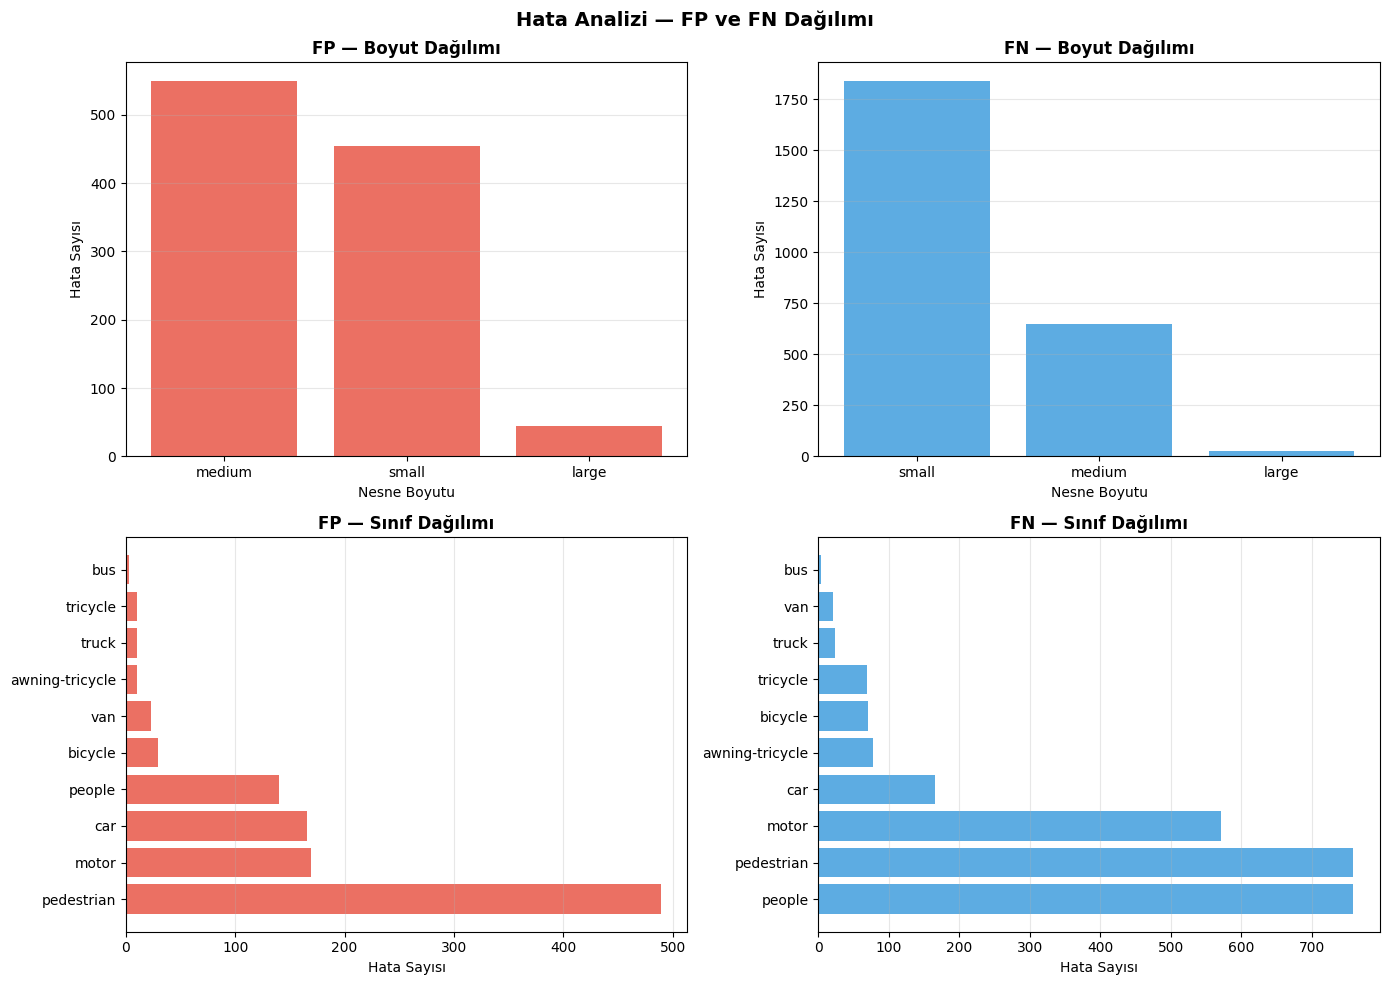

In [7]:
if error_records:
    df = pd.DataFrame(error_records)

    print('\n📊 Hata Özeti:')
    print(df.groupby(['type','size_cat']).size().unstack(fill_value=0))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # FP/FN boyut dağılımı
    for ax, err_type, color in zip(
            [axes[0,0], axes[0,1]],
            ['FP', 'FN'],
            ['#e74c3c', '#3498db']):
        sub = df[df['type']==err_type]
        counts = sub['size_cat'].value_counts()
        ax.bar(counts.index, counts.values, color=color, alpha=0.8)
        ax.set_title(f'{err_type} — Boyut Dağılımı', fontweight='bold')
        ax.set_xlabel('Nesne Boyutu')
        ax.set_ylabel('Hata Sayısı')
        ax.grid(True, alpha=0.3, axis='y')

    # FP/FN sınıf dağılımı
    for ax, err_type, color in zip(
            [axes[1,0], axes[1,1]],
            ['FP', 'FN'],
            ['#e74c3c', '#3498db']):
        sub = df[df['type']==err_type]
        counts = sub['cls_pred'].value_counts().head(10)
        ax.barh(counts.index, counts.values, color=color, alpha=0.8)
        ax.set_title(f'{err_type} — Sınıf Dağılımı', fontweight='bold')
        ax.set_xlabel('Hata Sayısı')
        ax.grid(True, alpha=0.3, axis='x')

    plt.suptitle('Hata Analizi — FP ve FN Dağılımı', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/error_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  error_records boş — dataset gerekli')

## 4️⃣ En Kötü FP ve FN Örneklerini Görselleştir

In [8]:
def visualize_error_samples(samples, title, color_bgr, out_name):
    if not samples:
        print(f'⚠️  {title} örneği bulunamadı')
        return
    n  = min(len(samples), 6)
    nc = 3
    nr = (n + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(6*nc, 5*nr))
    for i, (frame, bbox, img_name) in enumerate(samples[:n]):
        x1,y1,x2,y2 = map(int, bbox)
        vis = frame.copy()
        cv2.rectangle(vis, (x1,y1), (x2,y2), color_bgr, 3)
        # crop + padding
        pad  = 60
        cx1  = max(0, x1-pad); cy1 = max(0, y1-pad)
        cx2  = min(frame.shape[1], x2+pad); cy2 = min(frame.shape[0], y2+pad)
        crop = vis[cy1:cy2, cx1:cx2]
        r, c = divmod(i, nc)
        ax   = axes[r,c] if nr > 1 else axes[c]
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{img_name}', fontsize=8)
        ax.axis('off')

    # Kalan boş subplotlar
    for i in range(n, nr*nc):
        r, c = divmod(i, nc)
        ax   = axes[r,c] if nr > 1 else axes[c]
        ax.axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{out_name}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ {out_name} kaydedildi')


visualize_error_samples(
    fp_samples,
    'False Positive Örnekleri (Model nesne gördü ama yok)',
    (80, 80, 255),   # BGR kırmızı
    'false_positives.png'
)

visualize_error_samples(
    fn_samples,
    'False Negative Örnekleri (Gerçek nesne var, model kaçırdı)',
    (50, 200, 100),  # BGR yeşil
    'false_negatives.png'
)

Output hidden; open in https://colab.research.google.com to view.

## 5️⃣ Hata Modu Özeti — Rapor için

In [9]:
if error_records:
    df = pd.DataFrame(error_records)

    total_fp   = len(df[df['type']=='FP'])
    total_fn   = len(df[df['type']=='FN'])
    small_fp   = len(df[(df['type']=='FP') & (df['size_cat']=='small')])
    small_fn   = len(df[(df['type']=='FN') & (df['size_cat']=='small')])
    medium_fn  = len(df[(df['type']=='FN') & (df['size_cat']=='medium')])

    top_fp_cls = df[df['type']=='FP']['cls_pred'].value_counts().head(3).to_dict()
    top_fn_cls = df[df['type']=='FN']['cls_pred'].value_counts().head(3).to_dict()

    error_summary = {
        'total_fp':     total_fp,
        'total_fn':     total_fn,
        'small_fp':     small_fp,
        'small_fn':     small_fn,
        'medium_fn':    medium_fn,
        'pct_small_fp': round(100*small_fp/total_fp,  1) if total_fp  else 0,
        'pct_small_fn': round(100*small_fn/total_fn,  1) if total_fn  else 0,
        'top_fp_classes': top_fp_cls,
        'top_fn_classes': top_fn_cls,
    }

    with open(f'{PROJECT_DIR}/error_summary.json', 'w') as f:
        json.dump(error_summary, f, indent=2)

    df.to_csv(f'{PROJECT_DIR}/error_records.csv', index=False)

    print('📋 Hata Analizi Özeti (Rapor Bölüm 4 için):')
    print(f'  Toplam FP                : {total_fp}')
    print(f'  Toplam FN                : {total_fn}')
    print(f'  Küçük nesne FP (%<32px)  : {small_fp} ({error_summary["pct_small_fp"]}%)')
    print(f'  Küçük nesne FN (%<32px)  : {small_fn} ({error_summary["pct_small_fn"]}%)')
    print(f'  En çok FP veren sınıflar : {top_fp_cls}')
    print(f'  En çok FN veren sınıflar : {top_fn_cls}')
else:
    print('⚠️  Dataset olmadan hata özeti üretilemiyor')

print('\n✅ GÜN 14 TAMAMLANDI!')

📋 Hata Analizi Özeti (Rapor Bölüm 4 için):
  Toplam FP                : 1049
  Toplam FN                : 2519
  Küçük nesne FP (%<32px)  : 454 (43.3%)
  Küçük nesne FN (%<32px)  : 1842 (73.1%)
  En çok FP veren sınıflar : {'pedestrian': 489, 'motor': 169, 'car': 166}
  En çok FN veren sınıflar : {'people': 759, 'pedestrian': 759, 'motor': 571}

✅ GÜN 14 TAMAMLANDI!


---
## ✅ Gün 14 Özet
| Hata Modu | Beklenen Neden | Çözüm Önerisi |
|-----------|---------------|---------------|
| FP — küçük | Gürültü, texture | Confidence threshold artır |
| FN — küçük | Düşük çözünürlük | SAHI patch boyutunu küçült |
| FN — occluded | Üst üste binen nesneler | Augmentation: copy-paste |
| FP — sınıf karışıklığı | Görsel benzerlik | More class-specific augmentation |

**Sonraki (Gün 15 - ortak):** Tüm sayısal sonuçları çapraz kontrol